<a href="https://colab.research.google.com/github/harshitmogre/ai-learning-assistant/blob/main/02_Linear_Regression_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

___

 You just got some contract work with an Ecommerce company based in New York City that sells clothing online but they also have in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.
The company is trying to decide whether to focus their efforts on their mobile app experience or their website. They've hired you on contract to help them figure it out! Let's get started! Just follow the steps below to analyze the customer data

## Imports
** Import pandas, numpy, matplotlib,and seaborn. Then set %matplotlib inline
(You'll import sklearn as you need it.)**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


## Get the Data

We'll work with the Ecommerce Customers csv file from the company. It has Customer info, suchas Email, Address, and their color Avatar. Then it also has numerical value columns:

* Avg. Session Length: Average session of in-store style advice sessions.
* Time on App: Average time spent on App in minutes
* Time on Website: Average time spent on Website in minutes
* Length of Membership: How many years the customer has been a member.

** Read in the Ecommerce Customers csv file as a DataFrame called customers.**

In [3]:
customers = pd.read_csv("/content/Ecommerce Customers")

**Check the head of customers, and check out its info() and describe() methods.**

In [4]:
customers = pd.read_csv("/content/Ecommerce Customers")
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


## Exploratory Data Analysis

**Let's explore the data!**

For the rest of the exercise we'll only be using the numerical data of the csv file.
___
**Use seaborn to create a jointplot to compare the Time on Website and Yearly Amount Spent columns. Does the correlation make sense?**

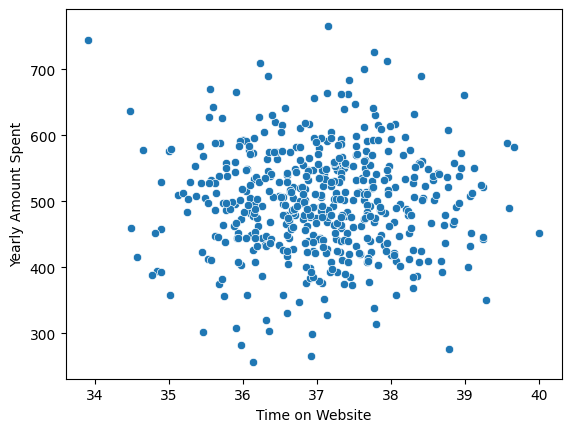

In [7]:
sns.scatterplot(x="Time on Website", y="Yearly Amount Spent",data=customers);

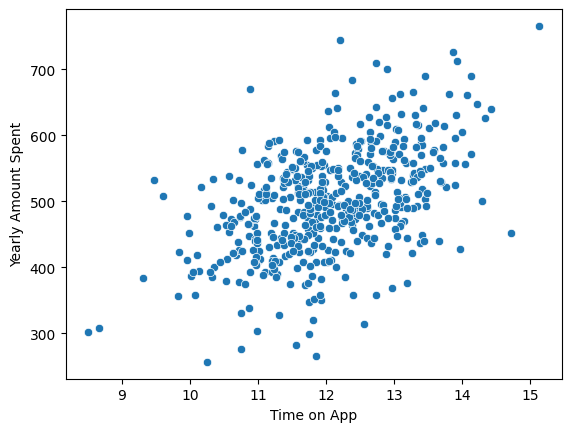

In [26]:
sns.scatterplot(x="Time on App", y="Yearly Amount Spent",data=customers);

** Do the same but with the Time on App column instead. **

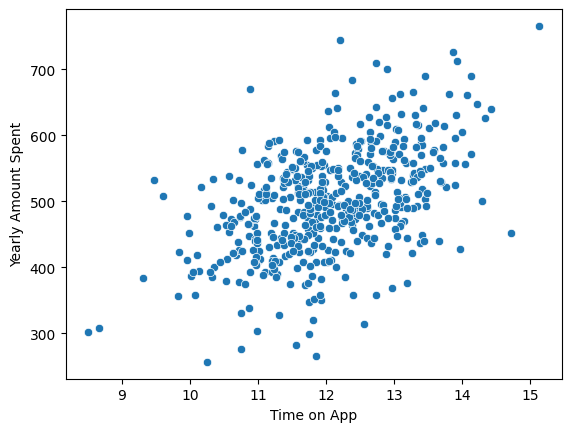

In [8]:
sns.scatterplot(x="Time on App", y="Yearly Amount Spent",data=customers);

** Use jointplot to create a 2D hex bin plot comparing Time on App and Length of Membership.**

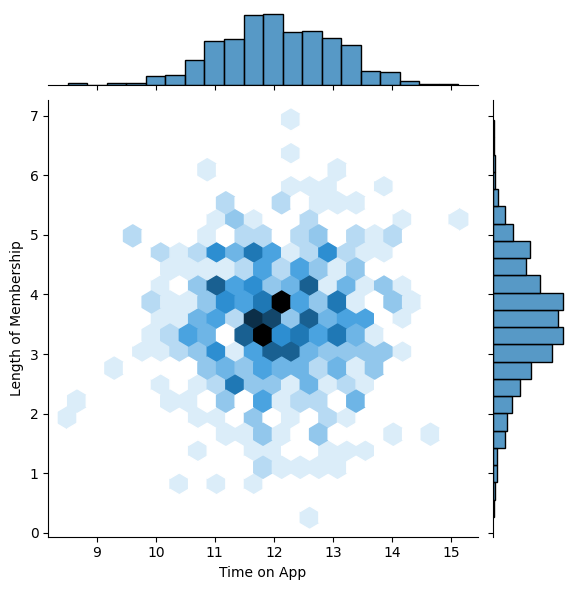

In [9]:
sns.jointplot( x="Time on App", y="Length of Membership", data=customers, kind="hex")

**Let's explore these types of relationships across the entire data set. Use [pairplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/axis_grids.html#plotting-pairwise-relationships-with-pairgrid-and-pairplot) to recreate the plot below.(Don't worry about the the colors)**

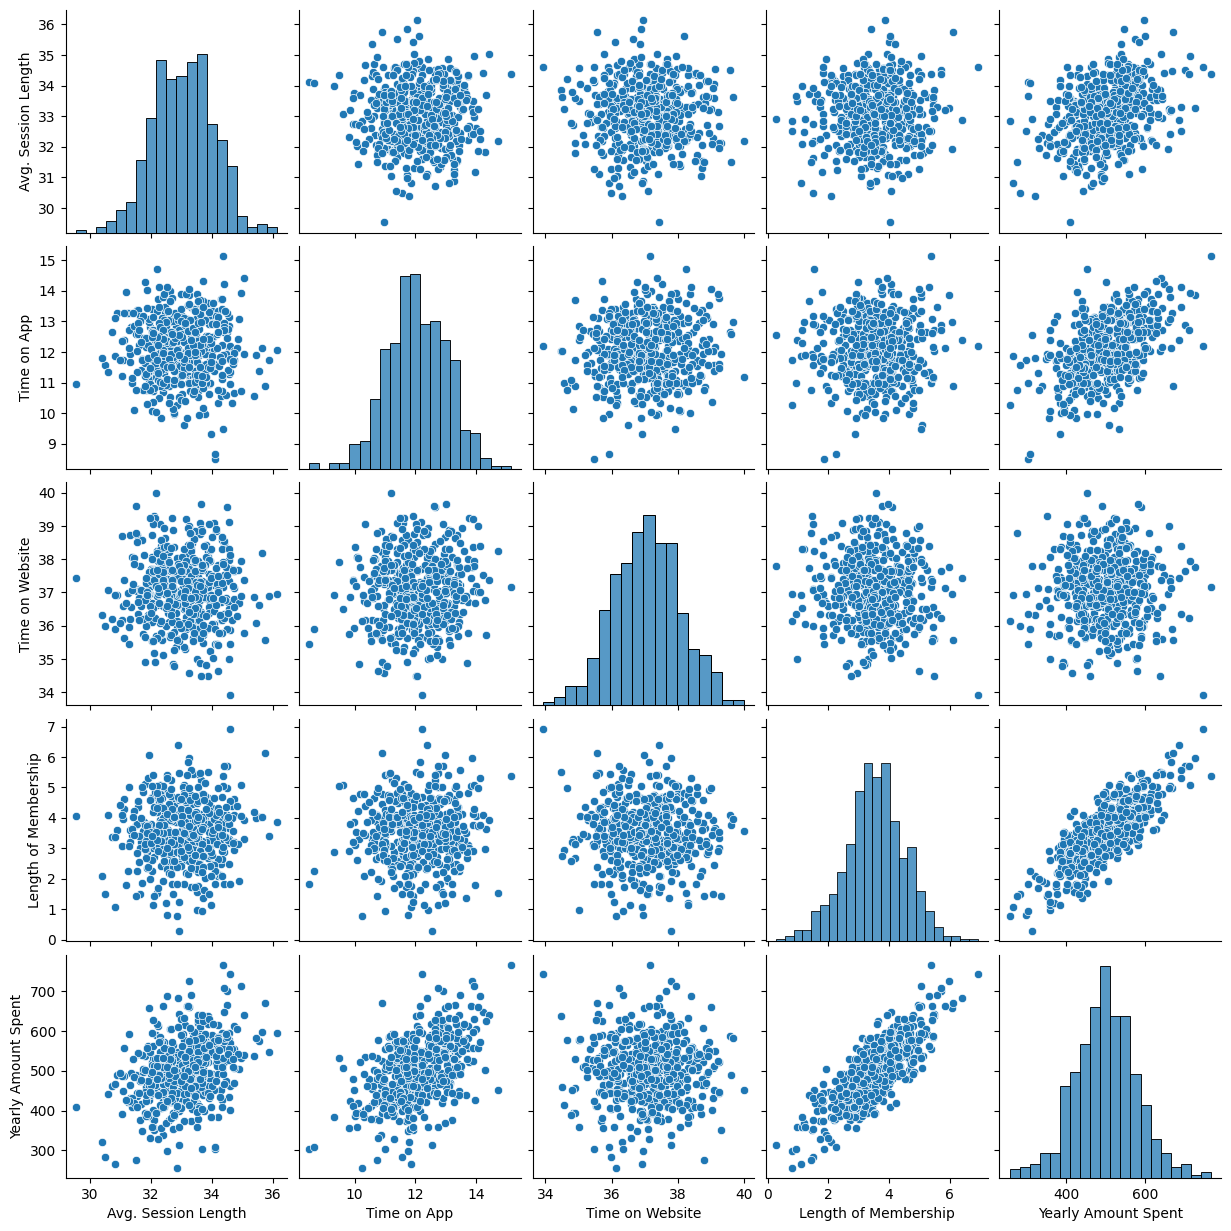

In [10]:
sns.pairplot(customers)

**Based off this plot what looks to be the most correlated feature with Yearly Amount Spent?**

**Create a linear model plot (using seaborn's lmplot) of  Yearly Amount Spent vs. Length of Membership. **

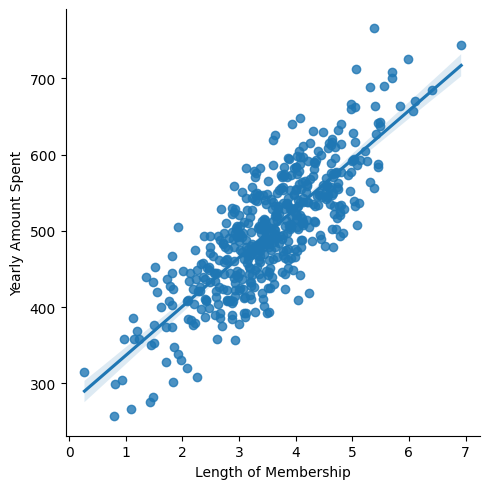

In [11]:
sns.lmplot( x="Length of Membership", y="Yearly Amount Spent", data=customers )

## Training and Testing Data

Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets.
** Set a variable X equal to the numerical features of the customers and a variable y equal to the "Yearly Amount Spent" column. **

In [12]:
X = customers[[ "Avg. Session Length", "Time on App", "Time on Website", "Length of Membership" ]]

In [13]:
y = customers["Yearly Amount Spent"]

** Use model_selection.train_test_split from sklearn to split the data into training and testing sets. Set test_size=0.3 and random_state=101**

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=101 )

## Training the Model

Now its time to train our model on our training data!

** Import LinearRegression from sklearn.linear_model **

In [16]:
from sklearn.linear_model import LinearRegression

**Create an instance of a LinearRegression() model named lm.**

In [17]:
lm = LinearRegression()

** Train/fit lm on the training data.**

In [18]:
lm.fit(X_train, y_train)

LinearRegression()

**Print out the coefficients of the model**

In [25]:
print(lm.coef_)
print(lm.intercept_)

[25.98154972 38.59015875  0.19040528 61.27909654]
-1047.9327822502391


## Predicting Test Data
Now that we have fit our model, let's evaluate its performance by predicting off the test values!

** Use lm.predict() to predict off the X_test set of the data.**

In [28]:
predictions = lm.predict(X_test);
print(predictions);

[456.44186104 402.72005312 409.2531539  591.4310343  590.01437275
 548.82396607 577.59737969 715.44428115 473.7893446  545.9211364
 337.8580314  500.38506697 552.93478041 409.6038964  765.52590754
 545.83973731 693.25969124 507.32416226 573.10533175 573.2076631
 397.44989709 555.0985107  458.19868141 482.66899911 559.2655959
 413.00946082 532.25727408 377.65464817 535.0209653  447.80070905
 595.54339577 667.14347072 511.96042791 573.30433971 505.02260887
 565.30254655 460.38785393 449.74727868 422.87193429 456.55615271
 598.10493696 449.64517443 615.34948995 511.88078685 504.37568058
 515.95249276 568.64597718 551.61444684 356.5552241  464.9759817
 481.66007708 534.2220025  256.28674001 505.30810714 520.01844434
 315.0298707  501.98080155 387.03842642 472.97419543 432.8704675
 539.79082198 590.03070739 752.86997652 558.27858232 523.71988382
 431.77690078 425.38411902 518.75571466 641.9667215  481.84855126
 549.69830187 380.93738919 555.18178277 403.43054276 472.52458887
 501.82927633 4

** Create a scatterplot of the real test values versus the predicted values. **

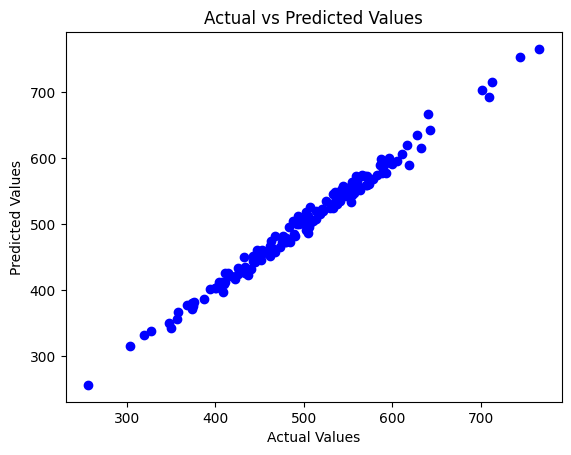

In [30]:
plt.scatter(y_test, predictions, color="blue")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

## Evaluating the Model

Let's evaluate our model performance by calculating the residual sum of squares and the explained variance score (R^2).

** Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error. Refer to the lecture or to Wikipedia for the formulas**

In [33]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error);
MAE = mean_absolute_error(y_test, predictions);
MSE = mean_squared_error(y_test, predictions);
RMSE = np.sqrt(MSE);
print("MAE: ",MAE);
print("MSE: ",MSE);
print("RMSE: ",RMSE);

MAE:  7.228148653430826
MSE:  79.81305165097427
RMSE:  8.933815066978624


## Residuals

You should have gotten a very good model with a good fit. Let's quickly explore the residuals to make sure everything was okay with our data.

**Plot a histogram of the residuals and make sure it looks normally distributed. Use either seaborn distplot, or just plt.hist().**

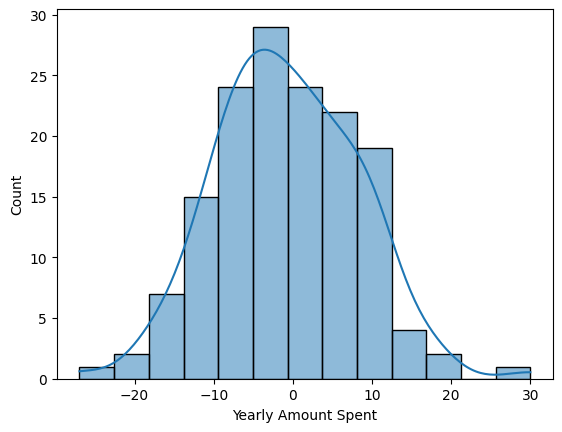

In [35]:
sns.histplot(y_test - predictions, kde=True)
plt.show()

## Conclusion
We still want to figure out the answer to the original question, do we focus our efforst on mobile app or website development? Or maybe that doesn't even really matter, and Membership Time is what is really important.  Let's see if we can interpret the coefficients at all to get an idea.

** Recreate the dataframe below. **

In [36]:
coeff_df = pd.DataFrame( lm.coef_, X.columns, columns=["Coefficient"])

coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


** How can you interpret these coefficients? **

*Answer here*

**Do you think the company should focus more on their mobile app or on their website?**

In [37]:
## Task 2
from sklearn.linear_model import LinearRegression
X_train_np = X_train.values
y_train_np = y_train.values
X_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np];
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train_np;

print("Intercept:")
print(theta[0])

print()

print("Coefficients:")
print(theta[1:])
X_test_np = X_test.values

X_test_b = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np];
predictions_scratch = X_test_b @ theta

print("Sklearn Intercept:")
print(lm.intercept_)

print()

print("Scratch Intercept:")
print(theta[0]);

comparison = pd.DataFrame({
    "Feature": X.columns,
    "Sklearn": lm.coef_,
    "Scratch": theta[1:]
})

comparison

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, predictions_scratch))

print("MSE :", mean_squared_error(y_test, predictions_scratch))

print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions_scratch)))

print("R² :", r2_score(y_test, predictions_scratch))
## now write linear regression code from scratch and match with output generated using sklearn library **

Intercept:
-1047.9327822493196

Coefficients:
[25.98154972 38.59015875  0.19040528 61.27909654]
Sklearn Intercept:
-1047.9327822502391

Scratch Intercept:
-1047.9327822493196
MAE : 7.228148653430899
MSE : 79.81305165102195
RMSE: 8.933815066981293
R² : 0.9890046246741169


*Answer here*